`Ce fichier contient les graphiques du modèle fédéré et la validation croisée. A lancer après la simulation (server.py + client0.py + client1.py)`

#### Bibliothèques et paramètres globaux

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import os
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
from common import creer_baseline, N_FEATURES, NUM_ROUNDS
import seaborn as sns

POIDS_PATH = 'poids_federes_finaux.npy'   # fichier sauvegardé par server.py
HIST_PATH = 'hist_global.json'            # fichier sauvegardé par server.py
N_FOLDS = 3

#### Chargement des données
- Chargement du dataset
- Suppresion des colonnes non petinentes et les lignes vides
- Choix des features et de la target
- Séparation des données pour l'entrainement et la validation
- Normalisation


In [27]:
print("Chargement des données...")
data = pd.read_csv("5g_ddos.csv").drop('index', axis=1).dropna()
cols_drop = ['label', 'Fwd Seg Size Min', 'Slice']
features = [c for c in data.drop(cols_drop, axis=1).columns]

X = data[features].values.astype(np.float32)
Y = data['label'].values.astype(np.float32)

_, X_test, _, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X)
X_test = scaler.transform(X_test).reshape(-1, N_FEATURES, 1)

print ("Données chargées")

Chargement des données...
Données chargées


#### Chargement des poids fédérés

In [28]:
if not os.path.exists(POIDS_PATH):
    print(f"\nErreur : '{POIDS_PATH}' introuvable.")
    print("Exécutez les fichiers dans l'ordre indiqué dans le readme")
    exit(1)

print(f"\nChargement des poids fédérés depuis '{POIDS_PATH}'...")
poids = np.load(POIDS_PATH, allow_pickle=True)
modele = creer_baseline()
# Mise à jour du modèle avec les poids fédérés
modele.set_weights(list(poids))
print("\n Modèle fédéré prêt")


Chargement des poids fédérés depuis 'poids_federes_finaux.npy'...

 Modèle fédéré prêt


#### Chargement de l'historique des rounds

In [29]:
if os.path.exists(HIST_PATH):
    with open(HIST_PATH, 'r') as f:
        HIST_GLOBAL = json.load(f)
    print ("Historique chargé")
else:
    print(f"\nAvertissement : '{HIST_PATH}' introuvable — graphiques de convergence ignorés.")
    exit(1)

Historique chargé


#### Evaluation des métriques du modèle fédéré

In [30]:
print("\n Évaluation finale du modele fédéré")

Y_predit = (modele.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
Y_reel = Y_test.astype(int)

exactitude = accuracy_score(Y_reel, Y_predit)*100
precision = precision_score(Y_reel, Y_predit, zero_division=0)*100
sensibilite = recall_score(Y_reel, Y_predit, zero_division=0)*100
f1 = f1_score(Y_reel, Y_predit, zero_division=0)*100
cm = confusion_matrix(Y_reel, Y_predit)
TN, FP, FN, TP = cm.ravel()
specificite  = (TN / (TN + FP))*100 if (TN + FP) > 0 else 0

print(f"  Exactitude : {exactitude:.2f}%")
print(f"  Précision : {precision:.2f}%")
print(f"  Sensibilité : {sensibilite:.2f}%")
print(f"  Spécificité : {specificite:.2f}%")
print(f"  F1-Score : {f1:.2f}%")


 Évaluation finale du modele fédéré
  Exactitude : 99.92%
  Précision : 99.91%
  Sensibilité : 100.00%
  Spécificité : 99.28%
  F1-Score : 99.95%


#### Cross-validation

In [31]:
print(f"\n CROSS VALIDATION {N_FOLDS}-FOLD DU MODÈLE FÉDÉRÉ")

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cv_accuracies = []
cv_f1s = []

for i, (_, val_idx) in enumerate(kf.split(X_test)):

    # Charger les poids fédérés — pas d'entraînement
    m_fold = creer_baseline()
    m_fold.set_weights(list(poids))

    y_pred_fold = (m_fold.predict(X_test[val_idx], verbose=0) > 0.5).astype(int).flatten()
    y_true_fold = Y_reel[val_idx]

    acc_fold = accuracy_score(y_true_fold, y_pred_fold)*100
    cv_accuracies.append(acc_fold)
    f1_fold = f1_score(y_true_fold, y_pred_fold, zero_division=0)*100
    cv_f1s.append(f1_fold)

    print(f"  Fold {i+1} : accuracy={acc_fold:.2f}%  f1={f1_fold:.2f}%")

print(f"\nAccuracy moyenne : {np.mean(cv_accuracies):.2f}% "
      f"(±{np.std(cv_accuracies):.2f}%)")
print(f" F1 moyen : {np.mean(cv_f1s):.2f}% "
      f"(±{np.std(cv_f1s):.2f}%)")


 CROSS VALIDATION 3-FOLD DU MODÈLE FÉDÉRÉ
  Fold 1 : accuracy=99.92%  f1=99.95%
  Fold 2 : accuracy=99.92%  f1=99.96%
  Fold 3 : accuracy=99.92%  f1=99.95%

Accuracy moyenne : 99.92% (±0.00%)
 F1 moyen : 99.95% (±0.00%)


#### Graphe 1 : Accuracy et Loss

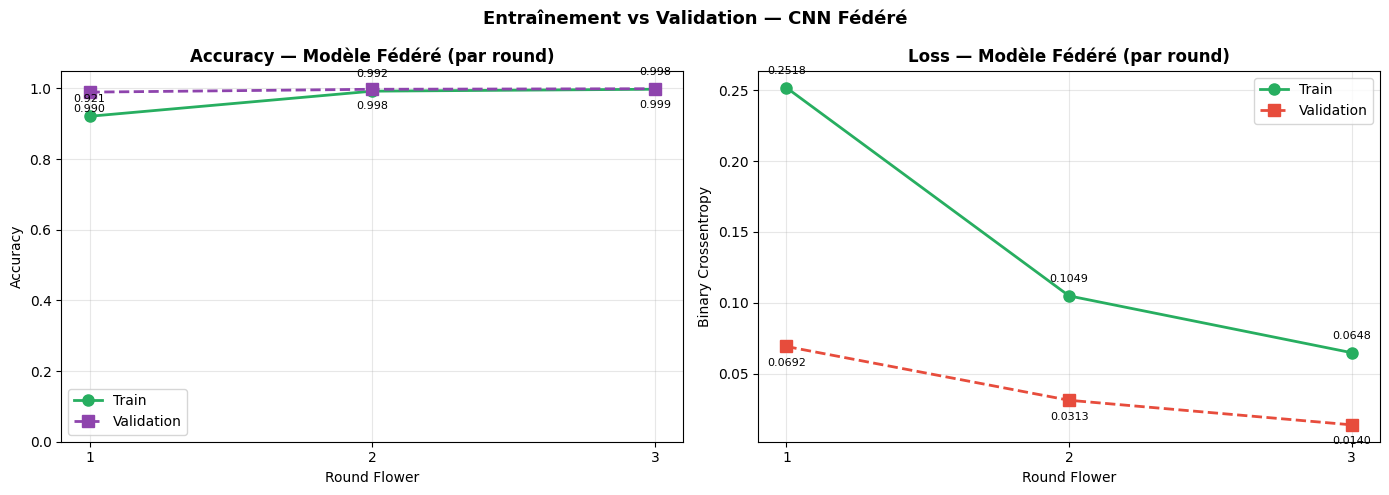

Sauvegardé : accuracy_loss_federe.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Fédéré 5G — Résultats & Évaluation', fontsize=16, fontweight='bold', y=0.98)

rounds = HIST_GLOBAL['round']

# --- Accuracy ---
ax = axes[0]
ax.plot(rounds, HIST_GLOBAL['train_acc'], marker='o', color='#27ae60', 
        lw=2, markersize=8, label='Train')
ax.plot(rounds, HIST_GLOBAL['val_acc'], marker='s', color='#8e44ad', 
        lw=2, markersize=8, label='Validation', ls='--')
for r, a in zip(rounds, HIST_GLOBAL['train_acc']):
    ax.annotate(f'{a:.3f}', (r, a), textcoords='offset points', 
                xytext=(0, 10), ha='center', fontsize=8)
for r, a in zip(rounds, HIST_GLOBAL['val_acc']):
    ax.annotate(f'{a:.3f}', (r, a), textcoords='offset points', 
                xytext=(0, -14), ha='center', fontsize=8)
ax.set_title('Accuracy — Modèle Fédéré (par round)', fontweight='bold')
ax.set_xlabel('Round Flower')
ax.set_ylabel('Accuracy')
ax.set_ylim([0.0, 1.05])
ax.set_xticks(rounds)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Loss ---
ax = axes[1]
ax.plot(rounds, HIST_GLOBAL['train_loss'], marker='o', color='#27ae60', 
        lw=2, markersize=8, label='Train')
ax.plot(rounds, HIST_GLOBAL['val_loss'], marker='s', color='#e74c3c', 
        lw=2, markersize=8, label='Validation', ls='--')
for r, l in zip(rounds, HIST_GLOBAL['train_loss']):
    ax.annotate(f'{l:.4f}', (r, l), textcoords='offset points', 
                xytext=(0, 10), ha='center', fontsize=8)
for r, l in zip(rounds, HIST_GLOBAL['val_loss']):
    ax.annotate(f'{l:.4f}', (r, l), textcoords='offset points', 
                xytext=(0, -14), ha='center', fontsize=8)
ax.set_title('Loss — Modèle Fédéré (par round)', fontweight='bold')
ax.set_xlabel('Round Flower')
ax.set_ylabel('Binary Crossentropy')
ax.set_xticks(rounds)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Entraînement vs Validation — CNN Fédéré', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resultats/accuracy_loss_federe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : accuracy_loss_federe.png')


#### Graphique 2 : Matrice de confusion du modèle fédéré

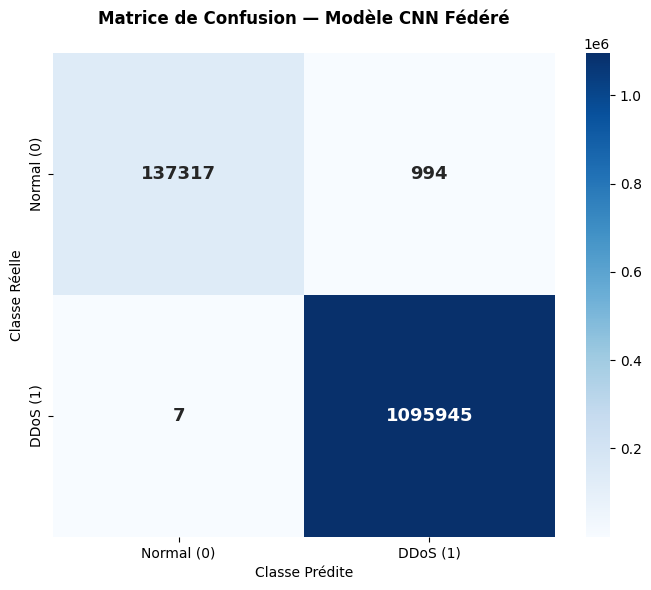

Sauvegardé : matrice_confusion_federe.png


In [33]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal (0)', 'DDoS (1)'],
            yticklabels=['Normal (0)', 'DDoS (1)'],
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title(f'Matrice de Confusion Modèle CNN Fédéré\n', fontweight='bold')
ax.set_ylabel('Classe Réelle') ; ax.set_xlabel('Classe Prédite')
plt.tight_layout()
plt.savefig('resultats/matrice_confusion_federe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : matrice_confusion_federe.png')


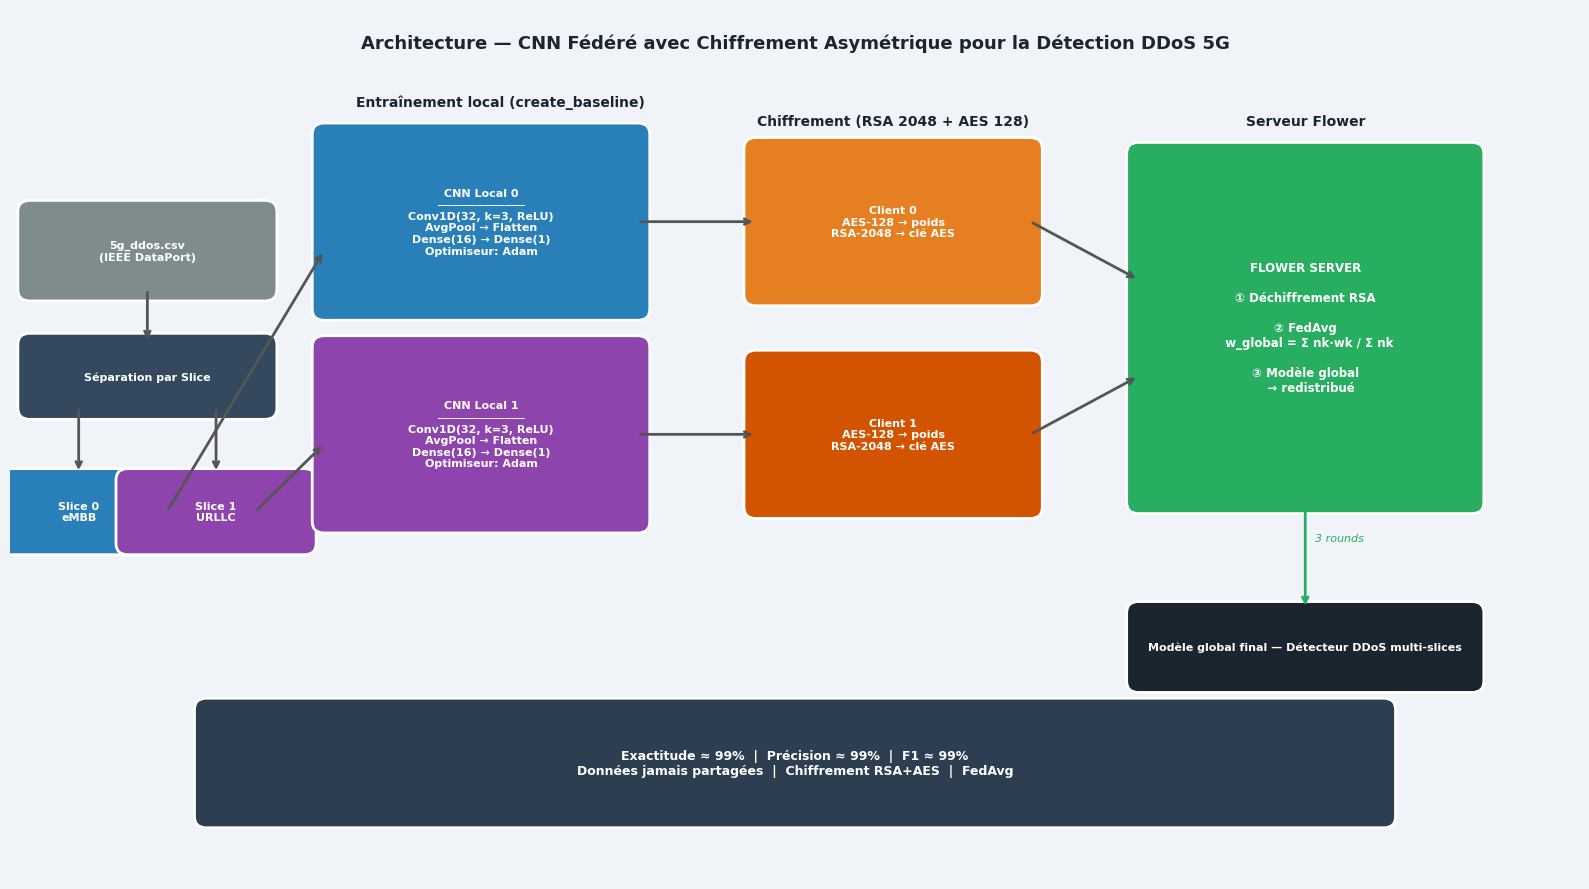

Sauvegardé : resultats/schema_global.png


In [42]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16) ; ax.set_ylim(0, 9) ; ax.axis('off')
fig.patch.set_facecolor('#f0f4f8')

def boite(x, y, w, h, txt, fc, tc='white', fs=9):
    ax.add_patch(mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle='round,pad=0.12', facecolor=fc, edgecolor='white', lw=2))
    ax.text(x, y, txt, ha='center', va='center', fontsize=fs,
            color=tc, fontweight='bold', multialignment='center')

def fleche(x1, y1, x2, y2, c='#555', lbl=''):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=c, lw=2))
    if lbl:
        ax.text((x1+x2)/2+0.1, (y1+y2)/2+0.15, lbl,
                fontsize=8, color=c, fontstyle='italic')

# Titre
ax.text(8, 8.6, 'Architecture — CNN Fédéré avec Chiffrement Asymétrique pour la Détection DDoS 5G',
        ha='center', fontsize=13, fontweight='bold', color='#1a252f')

# Dataset
boite(1.4, 6.5, 2.4, 0.8, '5g_ddos.csv\n(IEEE DataPort)', '#7f8c8d', fs=8)
fleche(1.4, 6.1, 1.4, 5.55)

# Slices
boite(1.4, 5.2, 2.4, 0.65, 'Séparation par Slice', '#34495e', fs=8)
fleche(0.7, 4.88, 0.7, 4.2)
fleche(2.1, 4.88, 2.1, 4.2)
boite(0.7, 3.8, 1.8, 0.65, 'Slice 0\neMBB', '#2980b9', fs=8)
boite(2.1, 3.8, 1.8, 0.65, 'Slice 1\nURLLC', '#8e44ad', fs=8)

# CNN locaux
ax.text(5.0, 8.0, 'Entraînement local (create_baseline)', ha='center',
        fontsize=10, fontweight='bold', color='#1a252f')
boite(4.8, 6.8, 3.2, 1.8,
      'CNN Local 0\n─────────────\nConv1D(32, k=3, ReLU)\nAvgPool → Flatten\nDense(16) → Dense(1)\nOptimiseur: Adam', '#2980b9', fs=8)
boite(4.8, 4.6, 3.2, 1.8,
      'CNN Local 1\n─────────────\nConv1D(32, k=3, ReLU)\nAvgPool → Flatten\nDense(16) → Dense(1)\nOptimiseur: Adam', '#8e44ad', fs=8)

fleche(1.6, 3.8, 3.2, 6.5)
fleche(2.5, 3.8, 3.2, 4.5)

# Chiffrement
ax.text(9.0, 7.8, 'Chiffrement (RSA 2048 + AES 128)', ha='center',
        fontsize=10, fontweight='bold', color='#1a252f')
boite(9.0, 6.8, 2.8, 1.5,
      'Client 0\nAES-128 → poids\nRSA-2048 → clé AES', '#e67e22', fs=8)
boite(9.0, 4.6, 2.8, 1.5,
      'Client 1\nAES-128 → poids\nRSA-2048 → clé AES', '#d35400', fs=8)

fleche(6.4, 6.8, 7.6, 6.8)
fleche(6.4, 4.6, 7.6, 4.6)

# Serveur Flower
ax.text(13.2, 7.8, 'Serveur Flower', ha='center',
        fontsize=10, fontweight='bold', color='#1a252f')
boite(13.2, 5.7, 3.4, 3.6,
      'FLOWER SERVER\n\n① Déchiffrement RSA\n\n② FedAvg\n  w_global = Σ nk·wk / Σ nk\n\n③ Modèle global\n   → redistribué', '#27ae60', fs=8.5)

fleche(10.4, 6.8, 11.5, 6.2)
fleche(10.4, 4.6, 11.5, 5.2)

# Retour modèle global
fleche(13.2, 3.9, 13.2, 2.8, '#27ae60', f'{NUM_ROUNDS} rounds')
boite(13.2, 2.4, 3.4, 0.7,
      'Modèle global final — Détecteur DDoS multi-slices', '#1a252f', fs=8)

# Métriques
boite(8, 1.2, 12, 1.1,
      f'Exactitude ≈ 99%  |  Précision ≈ 99%  |  F1 ≈ 99%\n'
      f'Données jamais partagées  |  Chiffrement RSA+AES  |  FedAvg',
      '#2c3e50', fs=9)

plt.tight_layout()
plt.savefig('schema_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : resultats/schema_global.png')